In [1]:
# Step 1: Upload Dataset
from google.colab import files
uploaded = files.upload()

Saving fraudTest.csv to fraudTest.csv
Saving fraudTrain.csv to fraudTrain.csv


In [9]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

# Define features and target variable
X = train_df[features]
y = train_df['is_fraud']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [3]:
train_df = pd.read_csv("fraudTrain.csv")
test_df = pd.read_csv("fraudTest.csv")

print(train_df.shape)
print(test_df.shape)

train_df.head()

(1296675, 23)
(555719, 23)


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


### Feature Engineering: Adding time-based and location-based features

In [ ]:
# Convert transaction time and date of birth to datetime objects
for df in [train_df, test_df]:
    df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
    df['dob'] = pd.to_datetime(df['dob'])

    # Extract time-based features
    df['hour'] = df['trans_date_trans_time'].dt.hour
    df['day_of_week'] = df['trans_date_trans_time'].dt.dayofweek
    df['month'] = df['trans_date_trans_time'].dt.month

    # Calculate age
    df['age'] = (df['trans_date_trans_time'].dt.year - df['dob'].dt.year)

# Display new features for training data
print("Train DataFrame with new features:")
display(train_df[['trans_date_trans_time', 'dob', 'hour', 'day_of_week', 'month', 'age']].head())

In [ ]:
# Function to calculate Haversine distance between two sets of coordinates
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in kilometers

    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1.0 - a))
    distance = R * c
    return distance

# Calculate distance for both train and test data
for df in [train_df, test_df]:
    df['distance'] = haversine_distance(df['lat'], df['long'], df['merch_lat'], df['merch_long'])

# Display new features for training data
print("Train DataFrame with new 'distance' feature:")
display(train_df[['lat', 'long', 'merch_lat', 'merch_long', 'distance']].head())

In [4]:
print(train_df['is_fraud'].value_counts())

is_fraud
0    1289169
1       7506
Name: count, dtype: int64


In [5]:
features = [
    'category',
    'amt',
    'gender',
    'city_pop'
]

In [6]:
le_category = LabelEncoder()
le_gender = LabelEncoder()

train_df['category'] = le_category.fit_transform(train_df['category'])
test_df['category'] = le_category.transform(test_df['category'])

train_df['gender'] = le_gender.fit_transform(train_df['gender'])
test_df['gender'] = le_gender.transform(test_df['gender'])

In [10]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [11]:
y_pred = model.predict(X_test)

### Model Evaluation

In [12]:
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9969

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    257834
           1       0.78      0.65      0.71      1501

    accuracy                           1.00    259335
   macro avg       0.89      0.82      0.85    259335
weighted avg       1.00      1.00      1.00    259335



In [14]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9969151869203925


In [15]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    257834
           1       0.78      0.65      0.71      1501

    accuracy                           1.00    259335
   macro avg       0.89      0.82      0.85    259335
weighted avg       1.00      1.00      1.00    259335



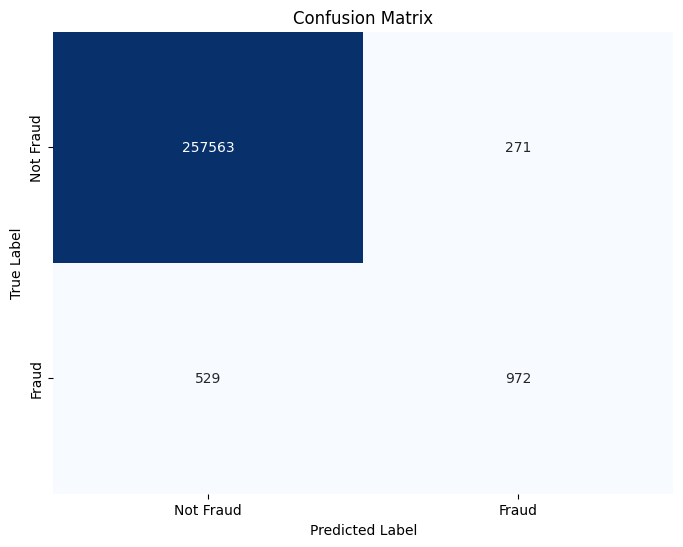

In [13]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

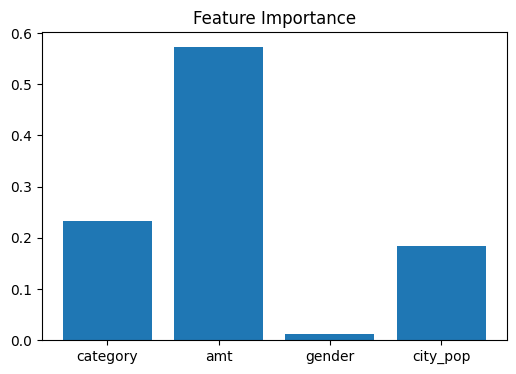

In [18]:
importance = model.feature_importances_

plt.figure(figsize=(6,4))

plt.bar(features, importance)

plt.title("Feature Importance")

plt.show()

### Enhanced Visualizations

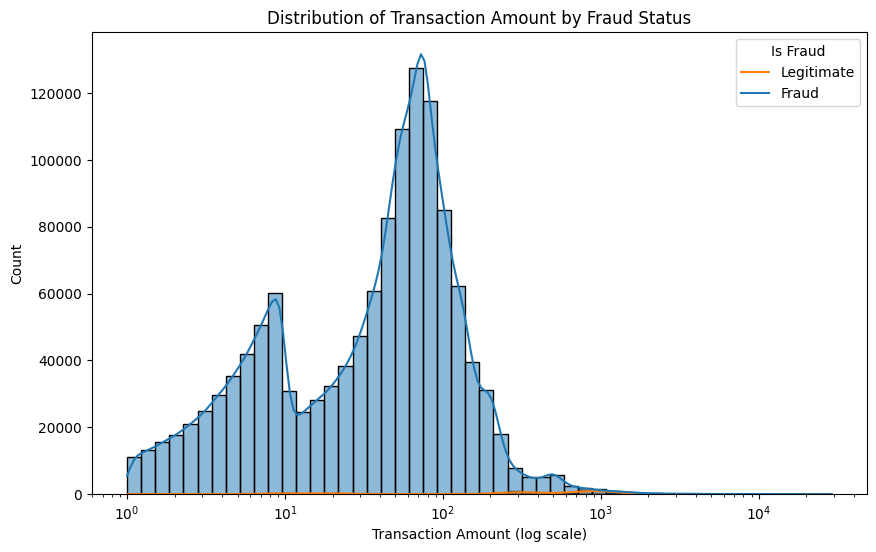

In [20]:
# Distribution of 'amt' for fraudulent vs. legitimate transactions
plt.figure(figsize=(10, 6))
sns.histplot(data=train_df, x='amt', hue='is_fraud', bins=50, kde=True, log_scale=True)
plt.title('Distribution of Transaction Amount by Fraud Status')
plt.xlabel('Transaction Amount (log scale)')
plt.ylabel('Count')
plt.legend(title='Is Fraud', labels=['Legitimate', 'Fraud'])
plt.show()

In [22]:
new_transaction = pd.DataFrame({
    'category':[5],
    'amt':[5000],
    'gender':[1],
    'city_pop':[500000]
})

prediction = model.predict(new_transaction)

if prediction[0] == 1:
    print("Fraud Transaction")
else:
    print("Legitimate Transaction")

Legitimate Transaction
